In [1]:
import os, pickle, json

CKPT_DIR = "/kaggle/working/gb_ckpts"
os.makedirs(CKPT_DIR, exist_ok=True)

In [2]:
!pip install dagshub mlflow optuna -q

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import dagshub
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from kaggle_secrets import UserSecretsClient
import warnings
warnings.filterwarnings('ignore')

dagshub.init (
    repo_owner="sophyrise",
    repo_name='ieee-cis-fraud-detection',
    mlflow=True
)

mlflow.set_experiment("Gradient Boosting")
print("✅ MLflow tracking URI:", mlflow.get_tracking_uri())

Accessing as sophyrise

Initialized MLflow to track repo "sophyrise/ieee-cis-fraud-detection"

Repository sophyrise/ieee-cis-fraud-detection initialized!

✅ MLflow tracking URI: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow


# **Cleaning**

In [4]:
with mlflow.start_run(run_name="GradientBoosting_Cleaning"):
    import gc
    import numpy as np
    import pandas as pd

    DATA_DIR = "/kaggle/input/competitions/ieee-fraud-detection"
    TXN_MISSING_THRESHOLD = 0.80
    ID_MISSING_THRESHOLD = 0.95
    NEAR_CONSTANT_THRESHOLD = 0.99

    # load
    train_txn = pd.read_csv(f"{DATA_DIR}/train_transaction.csv")
    train_id  = pd.read_csv(f"{DATA_DIR}/train_identity.csv")
    test_txn  = pd.read_csv(f"{DATA_DIR}/test_transaction.csv")
    test_id   = pd.read_csv(f"{DATA_DIR}/test_identity.csv")

    # fix id-01 vs id_01
    test_id.columns = test_id.columns.str.replace("-", "_", regex=False)

    # merge
    train = train_txn.merge(train_id, on="TransactionID", how="left")
    test  = test_txn.merge(test_id, on="TransactionID", how="left")

    del train_txn, train_id, test_txn, test_id
    gc.collect()

    # split target
    y_train = train["isFraud"].astype(np.int8)
    X_train = train.drop(columns=["isFraud", "TransactionID"])
    X_test  = test.drop(columns=["TransactionID"])

    del train, test
    gc.collect()

    # drop high-missing
    id_like_cols = [c for c in X_train.columns if c.startswith("id_") or c in ["DeviceType", "DeviceInfo"]]
    txn_like_cols = [c for c in X_train.columns if c not in id_like_cols]
    missing_ratio = X_train.isnull().mean()

    drop_txn = [c for c in txn_like_cols if missing_ratio[c] > TXN_MISSING_THRESHOLD]
    drop_id  = [c for c in id_like_cols if missing_ratio[c] > ID_MISSING_THRESHOLD]
    drop_missing = drop_txn + drop_id

    X_train = X_train.drop(columns=drop_missing)
    X_test  = X_test.drop(columns=[c for c in drop_missing if c in X_test.columns])

    # drop near-constant
    near_constant_cols = []
    for col in X_train.columns:
        top_freq = X_train[col].value_counts(dropna=False, normalize=True).iloc[0]
        if top_freq > NEAR_CONSTANT_THRESHOLD:
            near_constant_cols.append(col)

    X_train = X_train.drop(columns=near_constant_cols)
    X_test  = X_test.drop(columns=[c for c in near_constant_cols if c in X_test.columns])

    # align test columns
    for col in X_train.columns:
        if col not in X_test.columns:
            X_test[col] = np.nan
    X_test = X_test[X_train.columns]

    # log
    mlflow.log_param("txn_missing_threshold", TXN_MISSING_THRESHOLD)
    mlflow.log_param("id_missing_threshold", ID_MISSING_THRESHOLD)
    mlflow.log_param("near_constant_threshold", NEAR_CONSTANT_THRESHOLD)

    mlflow.log_metric("train_rows", int(X_train.shape[0]))
    mlflow.log_metric("test_rows", int(X_test.shape[0]))
    mlflow.log_metric("final_features", int(X_train.shape[1]))
    mlflow.log_metric("fraud_rate", float(y_train.mean()))
    mlflow.log_metric("dropped_missing_cols", int(len(drop_missing)))
    mlflow.log_metric("dropped_near_constant_cols", int(len(near_constant_cols)))

    print(f"X_train_clean: {X_train.shape}")
    print(f"X_test_clean:  {X_test.shape}")

    # keep for next cells
    X_train_clean = X_train
    X_test_clean = X_test
    y_train_clean = y_train

X_train_clean: (590540, 353)
X_test_clean:  (506691, 353)
🏃 View run GradientBoosting_Cleaning at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/6/runs/5b3048a3539d4b0d84d9678940f281d3
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/6


# **Feature Engineering**

In [5]:
with mlflow.start_run(run_name="GradientBoosting_FeatureEngineering"):
    from sklearn.impute import SimpleImputer

    X_train = X_train_clean.copy()
    X_test = X_test_clean.copy()
    y_train = y_train_clean.copy()

    X_train["TransactionAmt_log"] = np.log1p(X_train["TransactionAmt"].clip(lower=0))
    X_test["TransactionAmt_log"] = np.log1p(X_test["TransactionAmt"].clip(lower=0))

    X_train["hour_sin"] = np.sin(2 * np.pi * ((X_train["TransactionDT"] // 3600) % 24) / 24)
    X_train["hour_cos"] = np.cos(2 * np.pi * ((X_train["TransactionDT"] // 3600) % 24) / 24)
    X_test["hour_sin"] = np.sin(2 * np.pi * ((X_test["TransactionDT"] // 3600) % 24) / 24)
    X_test["hour_cos"] = np.cos(2 * np.pi * ((X_test["TransactionDT"] // 3600) % 24) / 24)

    X_train = X_train.drop(columns=["TransactionDT"], errors="ignore")
    X_test = X_test.drop(columns=["TransactionDT"], errors="ignore")

    cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
    num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

    num_imp = SimpleImputer(strategy="median")
    X_train[num_cols] = num_imp.fit_transform(X_train[num_cols])
    X_test[num_cols] = num_imp.transform(X_test[num_cols])

    cat_maps = {}
    for c in cat_cols:
        uniq = pd.Series(X_train[c].astype(str).unique())
        mapping = {v: i for i, v in enumerate(uniq)}
        cat_maps[c] = mapping
        X_train[c] = X_train[c].astype(str).map(mapping).fillna(-1).astype(np.int32)
        X_test[c] = X_test[c].astype(str).map(mapping).fillna(-1).astype(np.int32)

    X_test = X_test.reindex(columns=X_train.columns, fill_value=-1)

    mlflow.log_metric("features_after_fe", int(X_train.shape[1]))
    mlflow.log_metric("cat_cols_encoded", int(len(cat_cols)))

    print("X_train_fe:", X_train.shape)
    print("X_test_fe: ", X_test.shape)

    X_train_fe_gb = X_train
    X_test_fe_gb = X_test
    y_train_fe_gb = y_train

X_train_fe: (590540, 355)
X_test_fe:  (506691, 355)
🏃 View run GradientBoosting_FeatureEngineering at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/6/runs/dc1c5bdfde1441e98f7f4d96ef738cc8
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/6


In [6]:
print(X_train_fe_gb.shape, X_test_fe_gb.shape)
assert X_train_fe_gb.shape[1] == X_test_fe_gb.shape[1]
print("object cols left:", X_train_fe_gb.select_dtypes(include=["object"]).shape[1])

(590540, 355) (506691, 355)
object cols left: 0


# **Feature Selection**

In [7]:
with mlflow.start_run(run_name="GradientBoosting_FeatureSelection"):
    X_train = X_train_fe_gb.copy()
    X_test = X_test_fe_gb.copy()

    X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
    X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

    nu = X_train.nunique(dropna=False)
    const_cols = nu[nu <= 1].index.tolist()
    X_train = X_train.drop(columns=const_cols, errors="ignore")
    X_test = X_test.drop(columns=const_cols, errors="ignore")

    num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

    sample_n = min(120_000, len(X_train))
    idx = np.random.RandomState(42).choice(len(X_train), size=sample_n, replace=False)
    corr = X_train.iloc[idx][num_cols].corr().abs()

    upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
    drop_corr = [c for c in upper.columns if (upper[c] > 0.98).any()]

    X_train = X_train.drop(columns=drop_corr, errors="ignore")
    X_test = X_test.drop(columns=drop_corr, errors="ignore")

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    mlflow.log_metric("dropped_const", len(const_cols))
    mlflow.log_metric("dropped_corr", len(drop_corr))
    mlflow.log_metric("features_after_fs", int(X_train.shape[1]))

    print("X_train_fs:", X_train.shape)

    X_train_final_gb = X_train
    X_test_final_gb = X_test

X_train_fs: (590540, 306)
🏃 View run GradientBoosting_FeatureSelection at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/6/runs/e6029569a0a94c3ebd505bac62bc2c4c
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/6


In [8]:
print(X_train_final_gb.shape, X_test_final_gb.shape)
assert X_train_final_gb.shape[1] == X_test_final_gb.shape[1]

(590540, 306) (506691, 306)


# **Training**

In [9]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd
import mlflow
import mlflow.sklearn
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

import os, pickle, json

CKPT_DIR = "/kaggle/working/gb_ckpts"
os.makedirs(CKPT_DIR, exist_ok=True)


X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_final_gb, y_train_fe_gb,
    test_size=0.2, random_state=42, stratify=y_train_fe_gb
)

X_tr_sample = X_tr.iloc[
    np.random.RandomState(42).choice(len(X_tr), size=100_000, replace=False)
]
y_tr_sample = y_tr.iloc[
    np.random.RandomState(42).choice(len(y_tr), size=100_000, replace=False)
]

print(f"Train: {X_tr.shape} | Val: {X_val.shape} | Sample: {X_tr_sample.shape}")

Train: (472432, 306) | Val: (118108, 306) | Sample: (100000, 306)


In [10]:
with mlflow.start_run(run_name="GB_Baseline"):
    mlflow.log_param("n_estimators",  100)
    mlflow.log_param("max_depth",     3)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("subsample",     0.8)
    mlflow.log_param("note",          "default params, 100k sample")

    clf = GradientBoostingClassifier(
        n_estimators=100, max_depth=3,
        learning_rate=0.1, subsample=0.8,
        random_state=42
    )
    clf.fit(X_tr_sample, y_tr_sample)

    train_auc_baseline = roc_auc_score(y_tr_sample, clf.predict_proba(X_tr_sample)[:, 1])
    val_auc_baseline   = roc_auc_score(y_val,       clf.predict_proba(X_val)[:, 1])

    mlflow.log_metric("train_auc",   round(train_auc_baseline, 5))
    mlflow.log_metric("val_auc",     round(val_auc_baseline,   5))
    mlflow.log_metric("overfit_gap", round(train_auc_baseline - val_auc_baseline, 5))

    print(f"[Baseline] Train: {train_auc_baseline:.4f} | Val: {val_auc_baseline:.4f} | Gap: {train_auc_baseline - val_auc_baseline:.4f}")
    
    with open("/kaggle/working/gb_baseline_results.pkl", "wb") as f:
        pickle.dump({"train_auc": train_auc_baseline, "val_auc": val_auc_baseline}, f)

[Baseline] Train: 0.8755 | Val: 0.8714 | Gap: 0.0040
🏃 View run GB_Baseline at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/6/runs/15e775fefdf84582a95b8e85cab564a4
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/6


In [11]:
est_results = []
for n_est in [50, 100, 200]:
    with mlflow.start_run(run_name=f"GB_nestimators_{n_est}"):
        mlflow.log_param("n_estimators",      n_est)
        mlflow.log_param("max_depth",         3)
        mlflow.log_param("learning_rate",     0.1)
        mlflow.log_param("subsample",         0.8)
        mlflow.log_param("train_sample_size", 100_000)

        clf = GradientBoostingClassifier(
            n_estimators=n_est, max_depth=3,
            learning_rate=0.1, subsample=0.8,
            random_state=42
        )
        clf.fit(X_tr_sample, y_tr_sample)

        train_auc = roc_auc_score(y_tr_sample, clf.predict_proba(X_tr_sample)[:, 1])
        val_auc   = roc_auc_score(y_val,       clf.predict_proba(X_val)[:, 1])
        gap = train_auc - val_auc

        mlflow.log_metric("train_auc",   round(train_auc, 5))
        mlflow.log_metric("val_auc",     round(val_auc,   5))
        mlflow.log_metric("overfit_gap", round(gap, 5))

        est_results.append({"n_estimators": n_est, "train_auc": train_auc,
                             "val_auc": val_auc, "gap": gap})
        print(f"  n_estimators={n_est:<4} | Train: {train_auc:.4f} | Val: {val_auc:.4f} | Gap: {gap:.4f}")

est_df = pd.DataFrame(est_results).set_index("n_estimators")
best_n_est = int(est_df["val_auc"].idxmax())
print(f"\n-> Best n_estimators: {best_n_est}")

with open("/kaggle/working/gb_est_results.pkl", "wb") as f:
    pickle.dump({"results": est_results, "best_n_est": best_n_est}, f)

  n_estimators=50   | Train: 0.8639 | Val: 0.8636 | Gap: 0.0003
🏃 View run GB_nestimators_50 at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/6/runs/d1ec961274594f8ea89ec158fd32bd50
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/6
  n_estimators=100  | Train: 0.8755 | Val: 0.8714 | Gap: 0.0040
🏃 View run GB_nestimators_100 at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/6/runs/99c1ec806729463cb739a4b943443d13
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/6
  n_estimators=200  | Train: 0.8927 | Val: 0.8825 | Gap: 0.0102
🏃 View run GB_nestimators_200 at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/6/runs/814b3b32a5c34277880be6095e33655b
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/6

-> Best n_estimators: 200


In [12]:
lr_results = []
for lr in [0.3, 0.1, 0.05]:
    with mlflow.start_run(run_name=f"GB_lr_{lr}"):
        mlflow.log_param("n_estimators",      best_n_est)
        mlflow.log_param("max_depth",         3)
        mlflow.log_param("learning_rate",     lr)
        mlflow.log_param("subsample",         0.8)
        mlflow.log_param("train_sample_size", 100_000)

        clf = GradientBoostingClassifier(
            n_estimators=best_n_est, max_depth=3,
            learning_rate=lr, subsample=0.8,
            random_state=42
        )
        clf.fit(X_tr_sample, y_tr_sample)

        train_auc = roc_auc_score(y_tr_sample, clf.predict_proba(X_tr_sample)[:, 1])
        val_auc   = roc_auc_score(y_val,       clf.predict_proba(X_val)[:, 1])
        gap = train_auc - val_auc

        mlflow.log_metric("train_auc",   round(train_auc, 5))
        mlflow.log_metric("val_auc",     round(val_auc,   5))
        mlflow.log_metric("overfit_gap", round(gap, 5))

        lr_results.append({"lr": lr, "train_auc": train_auc, "val_auc": val_auc, "gap": gap})
        print(f"  lr={lr:<5} | Train: {train_auc:.4f} | Val: {val_auc:.4f} | Gap: {gap:.4f}")

lr_df = pd.DataFrame(lr_results).set_index("lr")
best_lr = float(lr_df["val_auc"].idxmax())
print(f"\n-> Best lr: {best_lr}")

with open("/kaggle/working/gb_lr_results.pkl", "wb") as f:
    pickle.dump({"results": lr_results, "best_lr": best_lr}, f)

  lr=0.3   | Train: 0.9173 | Val: 0.8907 | Gap: 0.0266
🏃 View run GB_lr_0.3 at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/6/runs/154a1d3f50b14955b9a0048e2af93812
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/6
  lr=0.1   | Train: 0.8927 | Val: 0.8825 | Gap: 0.0102
🏃 View run GB_lr_0.1 at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/6/runs/64ca8c64d419453ca99f3f189e09ba49
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/6
  lr=0.05  | Train: 0.8758 | Val: 0.8726 | Gap: 0.0031
🏃 View run GB_lr_0.05 at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/6/runs/1704fa1b9bba4ea190ee64b4a4a632a4
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/6

-> Best lr: 0.3


In [13]:
depth_results = []
for depth in [2, 3, 4, 5]:
    with mlflow.start_run(run_name=f"GB_depth_{depth}"):
        mlflow.log_param("n_estimators",      best_n_est)
        mlflow.log_param("max_depth",         depth)
        mlflow.log_param("learning_rate",     best_lr)
        mlflow.log_param("subsample",         0.8)
        mlflow.log_param("train_sample_size", 100_000)

        clf = GradientBoostingClassifier(
            n_estimators=best_n_est, max_depth=depth,
            learning_rate=best_lr, subsample=0.8,
            random_state=42
        )
        clf.fit(X_tr_sample, y_tr_sample)

        train_auc = roc_auc_score(y_tr_sample, clf.predict_proba(X_tr_sample)[:, 1])
        val_auc   = roc_auc_score(y_val,       clf.predict_proba(X_val)[:, 1])
        gap = train_auc - val_auc

        mlflow.log_metric("train_auc",   round(train_auc, 5))
        mlflow.log_metric("val_auc",     round(val_auc,   5))
        mlflow.log_metric("overfit_gap", round(gap, 5))

        depth_results.append({"depth": depth, "train_auc": train_auc,
                               "val_auc": val_auc, "gap": gap})
        print(f"  depth={depth} | Train: {train_auc:.4f} | Val: {val_auc:.4f} | Gap: {gap:.4f}")

depth_df = pd.DataFrame(depth_results).set_index("depth")
best_depth = int(depth_df["val_auc"].idxmax())
print(f"\n-> Best depth: {best_depth}")

with open("/kaggle/working/gb_depth_results.pkl", "wb") as f:
    pickle.dump({"results": depth_results, "best_depth": best_depth}, f)

  depth=2 | Train: 0.8901 | Val: 0.8755 | Gap: 0.0147
🏃 View run GB_depth_2 at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/6/runs/ad54c010e3b34ae694553f4680ae4d7e
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/6
  depth=3 | Train: 0.9173 | Val: 0.8907 | Gap: 0.0266
🏃 View run GB_depth_3 at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/6/runs/a3cd8cf717d8491093c7dd881c840a27
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/6
  depth=4 | Train: 0.9436 | Val: 0.8908 | Gap: 0.0528
🏃 View run GB_depth_4 at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/6/runs/bdfc1953c1b14a7a9518a049e164d7b4
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/6
  depth=5 | Train: 0.9623 | Val: 0.8862 | Gap: 0.0761
🏃 View run GB_depth_5 at: https://dagshub.com/sophyrise/ie

In [14]:
sample_idx = np.random.RandomState(42).choice(len(X_train_final_gb), size=150_000, replace=False)
X_cv = X_train_final_gb.iloc[sample_idx]
y_cv = y_train_fe_gb.iloc[sample_idx]

with mlflow.start_run(run_name="GB_CrossValidation_5fold"):
    mlflow.log_param("n_estimators",   best_n_est)
    mlflow.log_param("max_depth",      best_depth)
    mlflow.log_param("learning_rate",  best_lr)
    mlflow.log_param("subsample",      0.8)
    mlflow.log_param("cv_folds",       5)
    mlflow.log_param("cv_sample_size", 150_000)

    clf_cv = GradientBoostingClassifier(
        n_estimators=best_n_est, max_depth=best_depth,
        learning_rate=best_lr, subsample=0.8,
        random_state=42
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(clf_cv, X_cv, y_cv, cv=cv, scoring="roc_auc")

    for i, score in enumerate(cv_scores):
        mlflow.log_metric("fold_auc", round(score, 5), step=i)

    cv_mean = cv_scores.mean()
    cv_std  = cv_scores.std()
    mlflow.log_metric("cv_mean_auc", round(cv_mean, 5))
    mlflow.log_metric("cv_std_auc",  round(cv_std,  5))

    print(f"CV folds: {[round(s, 4) for s in cv_scores]}")
    print(f"Mean: {cv_mean:.4f} | Std: {cv_std:.4f}")

with open("/kaggle/working/gb_cv_results.pkl", "wb") as f:
    pickle.dump({"cv_scores": cv_scores, "cv_mean": cv_mean, "cv_std": cv_std}, f)

CV folds: [np.float64(0.8989), np.float64(0.9026), np.float64(0.8893), np.float64(0.8893), np.float64(0.89)]
Mean: 0.8940 | Std: 0.0056
🏃 View run GB_CrossValidation_5fold at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/6/runs/ea5b59e786b44bbe9c17e480825f29c6
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/6


In [17]:
with mlflow.start_run(run_name="GB_Final_Pipeline") as run:
    mlflow.log_param("n_estimators",  best_n_est)
    mlflow.log_param("max_depth",     best_depth)
    mlflow.log_param("learning_rate", best_lr)
    mlflow.log_param("subsample",     0.8)
    mlflow.log_param("trained_on",    "full_train_set")

    final_pipe = Pipeline([
        ("clf", GradientBoostingClassifier(
            n_estimators=best_n_est, max_depth=best_depth,
            learning_rate=best_lr, subsample=0.8,
            random_state=42
        ))
    ])
    final_pipe.fit(X_train_final_gb, y_train_fe_gb)

    val_auc_final = roc_auc_score(y_val, final_pipe.predict_proba(X_val)[:, 1])
    mlflow.log_metric("val_auc", round(val_auc_final, 5))

    mlflow.sklearn.log_model(
        sk_model=final_pipe,
        artifact_path="gradient_boosting_pipeline",
        registered_model_name="GradientBoosting_FraudDetection"
    )

    MODEL_PATH = "/kaggle/working/gb_fraud_pipeline.pkl"
    with open(MODEL_PATH, "wb") as f:
        pickle.dump(final_pipe, f)
    mlflow.log_artifact(MODEL_PATH)

    print(f"Final Pipeline Val AUC: {val_auc_final:.4f}")
    print(f"Model saved to: {MODEL_PATH}")
    print(f"Run ID: {run.info.run_id}")

with open("/kaggle/working/gb_final_results.pkl", "wb") as f:
    pickle.dump({"val_auc_final": val_auc_final}, f)

2026/05/03 15:59:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 15:59:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'GradientBoosting_FraudDetection' already exists. Creating a new version of this model...
2026/05/03 16:00:04 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: GradientBoosting_FraudDetection, version 2
Created version '2' of model 'GradientBoosting_FraudDetection'.


Final Pipeline Val AUC: 0.9200
Model saved to: /kaggle/working/gb_fraud_pipeline.pkl
Run ID: afc4f381e9ee4cbb98458a494efa2ac0
🏃 View run GB_Final_Pipeline at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/6/runs/afc4f381e9ee4cbb98458a494efa2ac0
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/6


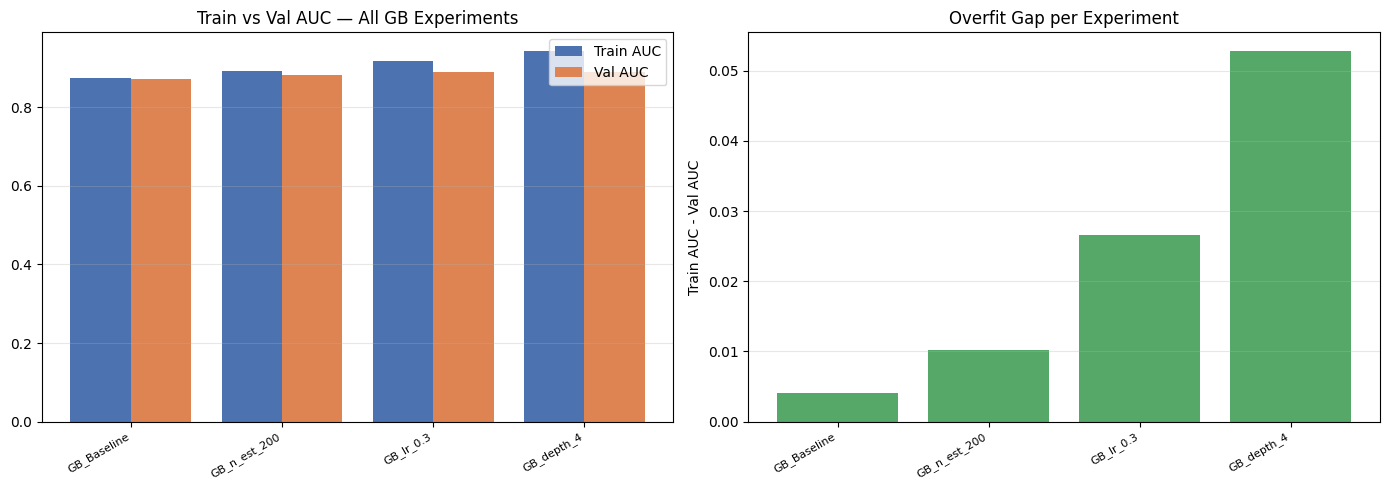

Saved and logged to MLflow


In [18]:
import matplotlib.pyplot as plt
import pandas as pd

results = {
    "GB_Baseline":         {"train_auc": train_auc_baseline,              "val_auc": val_auc_baseline},
    f"GB_n_est_{best_n_est}": {"train_auc": est_df.loc[best_n_est, "train_auc"], "val_auc": est_df.loc[best_n_est, "val_auc"]},
    f"GB_lr_{best_lr}":    {"train_auc": lr_df.loc[best_lr,    "train_auc"], "val_auc": lr_df.loc[best_lr,    "val_auc"]},
    f"GB_depth_{best_depth}": {"train_auc": depth_df.loc[best_depth, "train_auc"], "val_auc": depth_df.loc[best_depth, "val_auc"]},
    "GB_Final_Pipeline":   {"train_auc": None,                            "val_auc": val_auc_final},
}

df = pd.DataFrame(results).T.dropna()
x = range(len(df))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar([i - 0.2 for i in x], df["train_auc"], width=0.4, label="Train AUC", color="#4C72B0")
axes[0].bar([i + 0.2 for i in x], df["val_auc"],   width=0.4, label="Val AUC",   color="#DD8452")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(df.index, rotation=30, ha="right", fontsize=8)
axes[0].set_title("Train vs Val AUC — All GB Experiments")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

df["gap"] = df["train_auc"] - df["val_auc"]
axes[1].bar(df.index, df["gap"], color="#55A868")
axes[1].set_xticklabels(df.index, rotation=30, ha="right", fontsize=8)
axes[1].set_title("Overfit Gap per Experiment")
axes[1].set_ylabel("Train AUC - Val AUC")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("gb_training_summary.png", dpi=150, bbox_inches="tight")
mlflow.log_artifact("gb_training_summary.png")
plt.show()
print("Saved and logged to MLflow")